In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.shape

(9994, 21)

In [7]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [12]:
df.nunique()

Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64

In [14]:
df_clean = df.copy()

In [15]:
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

In [16]:
df_clean[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [17]:
df_clean["Postal Code"] = df_clean["Postal Code"].astype(str)

In [18]:
df_clean["Postal Code"].dtype

<StringDtype(na_value=nan)>

In [19]:
df_clean[["Sales", "Quantity", "Discount", "Profit"]].dtypes

Sales       float64
Quantity      int64
Discount    float64
Profit      float64
dtype: object

In [20]:
df_clean.isnull().sum().sum()

np.int64(0)

In [21]:
df_clean.duplicated().sum()

np.int64(0)

In [22]:
df_clean.shape

(9994, 21)

In [23]:
df_clean["Year"] = df_clean["Order Date"].dt.year

In [24]:
df_clean["Month"] = df_clean["Order Date"].dt.month

In [25]:
df_clean["Month Name"] = df_clean["Order Date"].dt.month_name()

In [26]:
df_clean["Quarter"] = df_clean["Order Date"].dt.quarter

In [27]:
df_clean["Profit Margin"] = (df_clean["Profit"] / df_clean["Sales"]) * 100

In [28]:
df_clean[["Order Date", "Year", "Month", "Month Name", "Quarter", "Sales", "Profit", "Profit Margin"]].head()

,Order Date,Year,Month,Month Name,Quarter,Sales,Profit,Profit Margin
0,2016-11-08,2016,11,November,4,261.9600,41.9136,16.00
1,2016-11-08,2016,11,November,4,731.9400,219.5820,30.00
2,2016-06-12,2016,6,June,2,14.6200,6.8714,47.00
3,2015-10-11,2015,10,October,4,957.5775,-383.0310,-40.00
4,2015-10-11,2015,10,October,4,22.3680,2.5164,11.25


In [29]:
df_clean.shape

(9994, 26)

In [30]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_quantity = df_clean["Quantity"].sum()
total_orders = df_clean["Order ID"].nunique()
total_customers = df_clean["Customer ID"].nunique()
total_products = df_clean["Product ID"].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity Sold:", total_quantity)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity Sold: 37873
Total Orders: 5009
Total Customers: 793
Total Products: 1862


In [31]:
yearly_performance = df_clean.groupby("Year").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).reset_index()

yearly_performance

,Year,Sales,Profit,Quantity
0,2014,484247.4981,49543.9741,7581
1,2015,470532.5090,61618.6037,7979
2,2016,609205.5980,81795.1743,9837
3,2017,733215.2552,93439.2696,12476


In [32]:
monthly_sales = df_clean.groupby(
    df_clean["Order Date"].dt.to_period("M")
)["Sales"].sum().reset_index()

monthly_sales.columns = ["Month", "Sales"]

monthly_sales

,Month,Sales
0,2014-01,14236.8950
1,2014-02,4519.8920
2,2014-03,55691.0090
3,2014-04,28295.3450
4,2014-05,23648.2870
5,2014-06,34595.1276
6,2014-07,33946.3930
7,2014-08,27909.4685
8,2014-09,81777.3508
9,2014-10,31453.3930


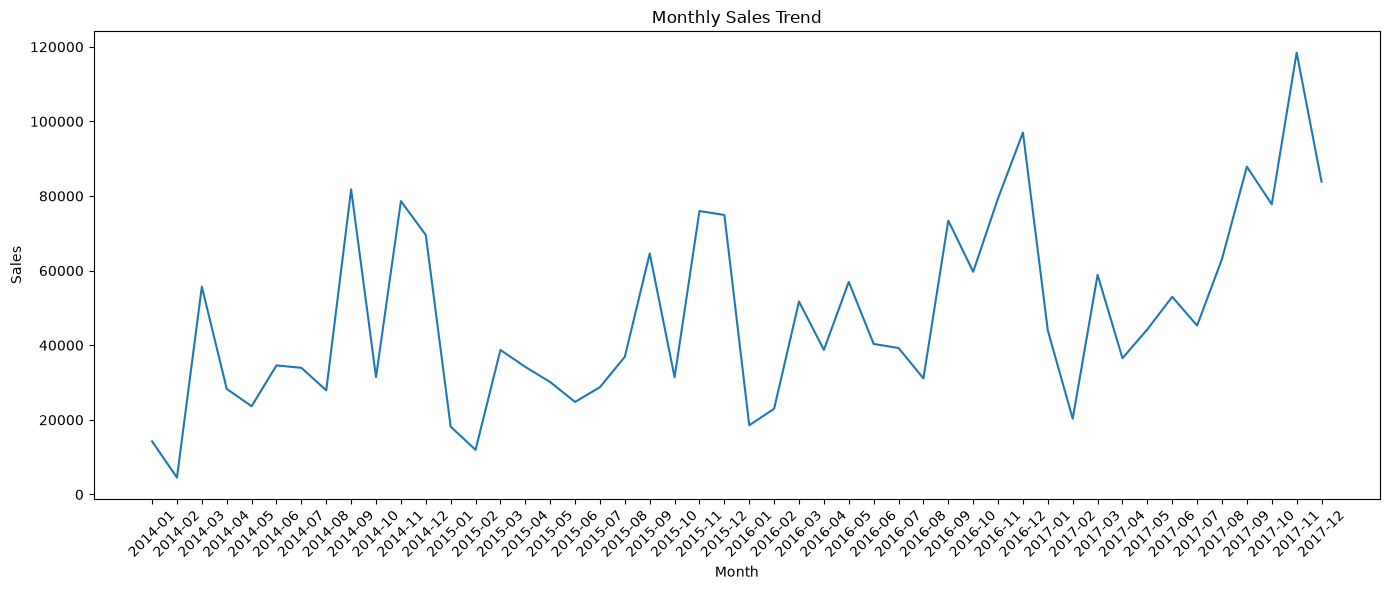

In [33]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales["Month"].astype(str), monthly_sales["Sales"])

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
yearly = df_clean.groupby("Year")[["Sales", "Profit"]].sum().reset_index()
yearly

,Year,Sales,Profit
0,2014,484247.4981,49543.9741
1,2015,470532.5090,61618.6037
2,2016,609205.5980,81795.1743
3,2017,733215.2552,93439.2696


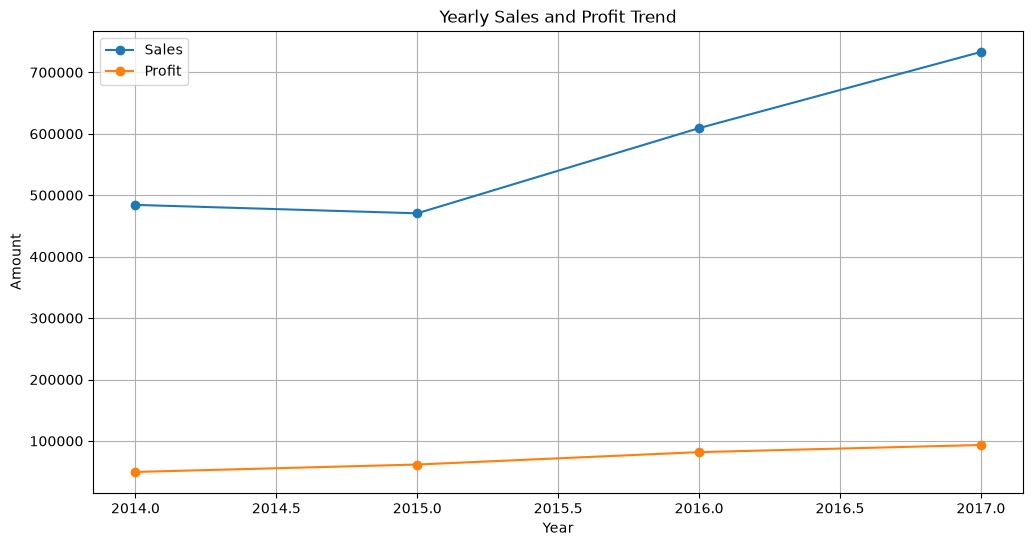

In [35]:
plt.figure(figsize=(12,6))
plt.plot(yearly["Year"], yearly["Sales"], marker="o", label="Sales")
plt.plot(yearly["Year"], yearly["Profit"], marker="o", label="Profit")
plt.title("Yearly Sales and Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
category = df_clean.groupby("Category")[["Sales", "Profit"]].sum().reset_index()
category

,Category,Sales,Profit
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008
2,Technology,836154.0330,145454.9481


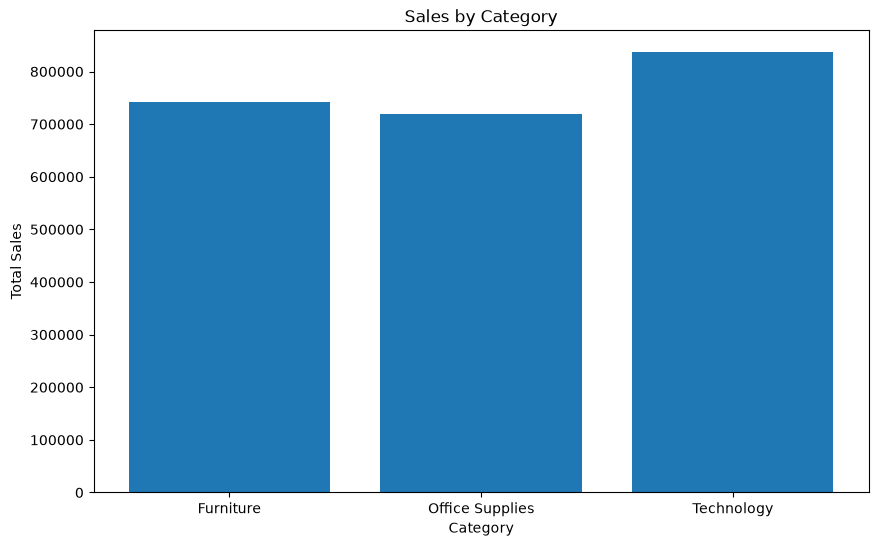

In [37]:
plt.figure(figsize=(10,6))
plt.bar(category["Category"], category["Sales"])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

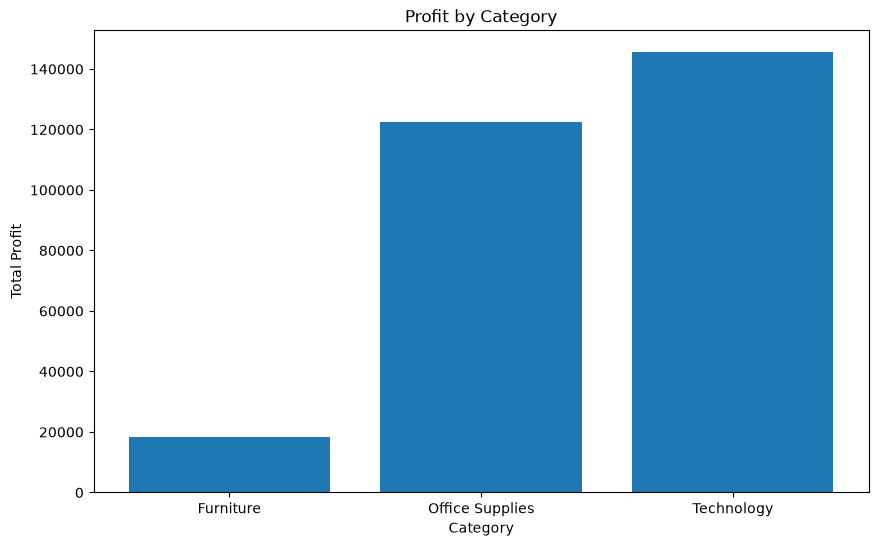

In [38]:
plt.figure(figsize=(10,6))
plt.bar(category["Category"], category["Profit"])
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

In [39]:
region = df_clean.groupby("Region")[["Sales", "Profit"]].sum().reset_index()
region

,Region,Sales,Profit
0,Central,501239.8908,39706.3625
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,West,725457.8245,108418.4489


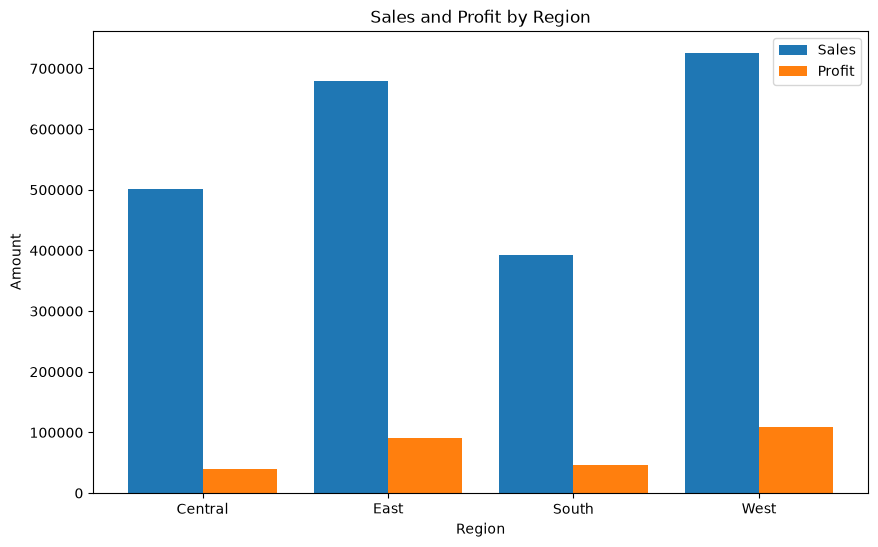

In [41]:
plt.figure(figsize=(10,6))
x = range(len(region))

plt.bar([i-0.2 for i in x], region["Sales"], width=0.4, label="Sales")
plt.bar([i+0.2 for i in x], region["Profit"], width=0.4, label="Profit")

plt.xticks(x, region["Region"])
plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.legend()
plt.show()

In [42]:
subcategory = df_clean.groupby("Sub-Category")[["Sales", "Profit"]].sum().reset_index()
subcategory.sort_values("Sales", ascending=False)

,Sub-Category,Sales,Profit
13,Phones,330007.0540,44515.7306
5,Chairs,328449.1030,26590.1663
14,Storage,223843.6080,21278.8264
16,Tables,206965.5320,-17725.4811
3,Binders,203412.7330,30221.7633
11,Machines,189238.6310,3384.7569
0,Accessories,167380.3180,41936.6357
6,Copiers,149528.0300,55617.8249
4,Bookcases,114879.9963,-3472.5560
1,Appliances,107532.1610,18138.0054


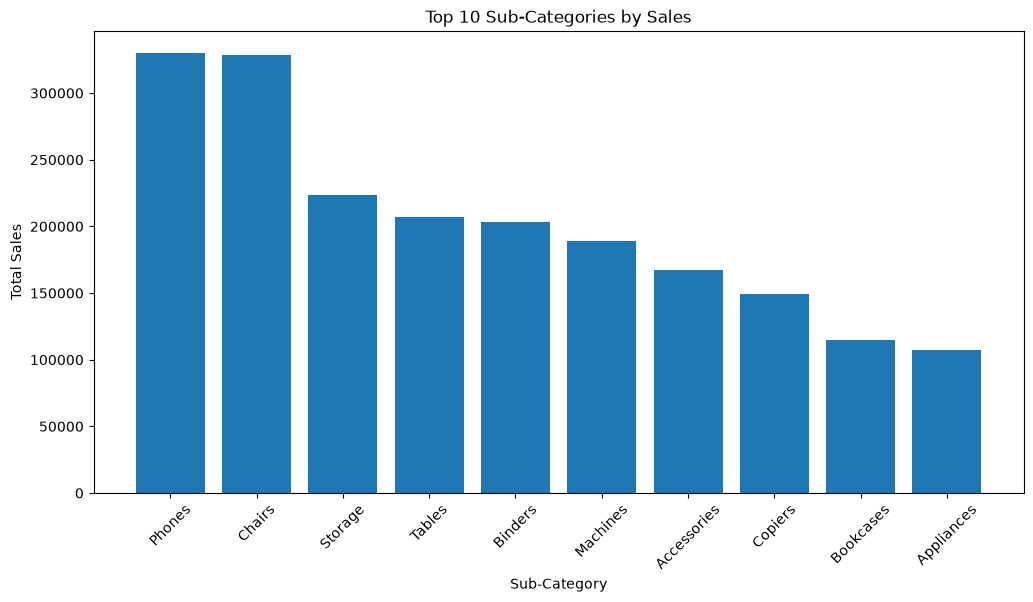

In [43]:
top10 = subcategory.sort_values("Sales", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10["Sub-Category"], top10["Sales"])
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

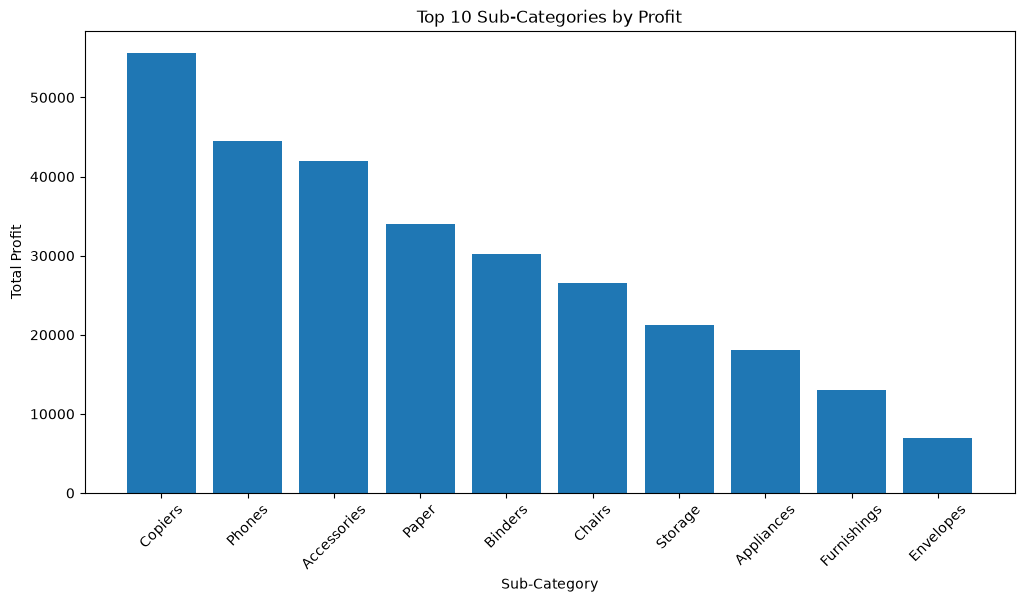

In [44]:
top_profit = subcategory.sort_values("Profit", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_profit["Sub-Category"], top_profit["Profit"])
plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

In [45]:
segment = df_clean.groupby("Segment")[["Sales", "Profit"]].sum().reset_index()
segment

,Segment,Sales,Profit
0,Consumer,1.161401e+06,134119.2092
1,Corporate,7.061464e+05,91979.1340
2,Home Office,4.296531e+05,60298.6785


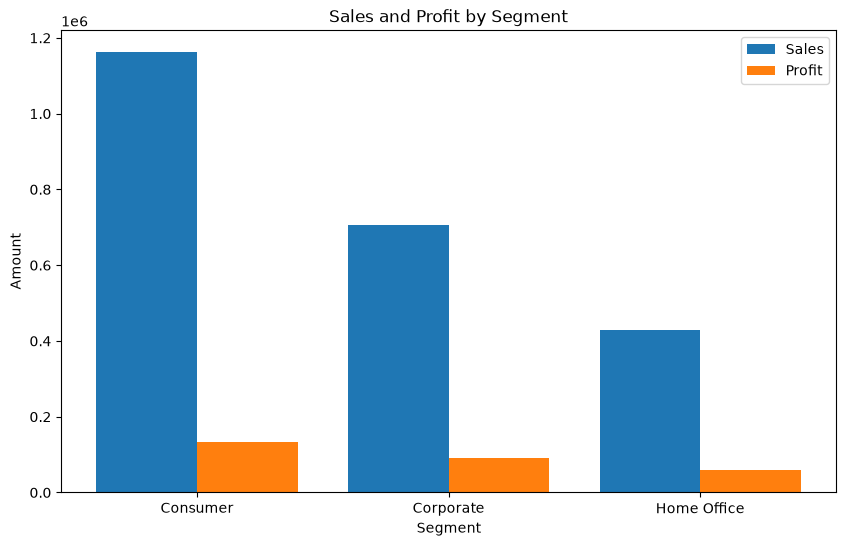

In [46]:
plt.figure(figsize=(10,6))
x = range(len(segment))
plt.bar([i-0.2 for i in x], segment["Sales"], width=0.4, label="Sales")
plt.bar([i+0.2 for i in x], segment["Profit"], width=0.4, label="Profit")
plt.xticks(x, segment["Segment"])
plt.title("Sales and Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Amount")
plt.legend()
plt.show()

In [47]:
top_customers = df_clean.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

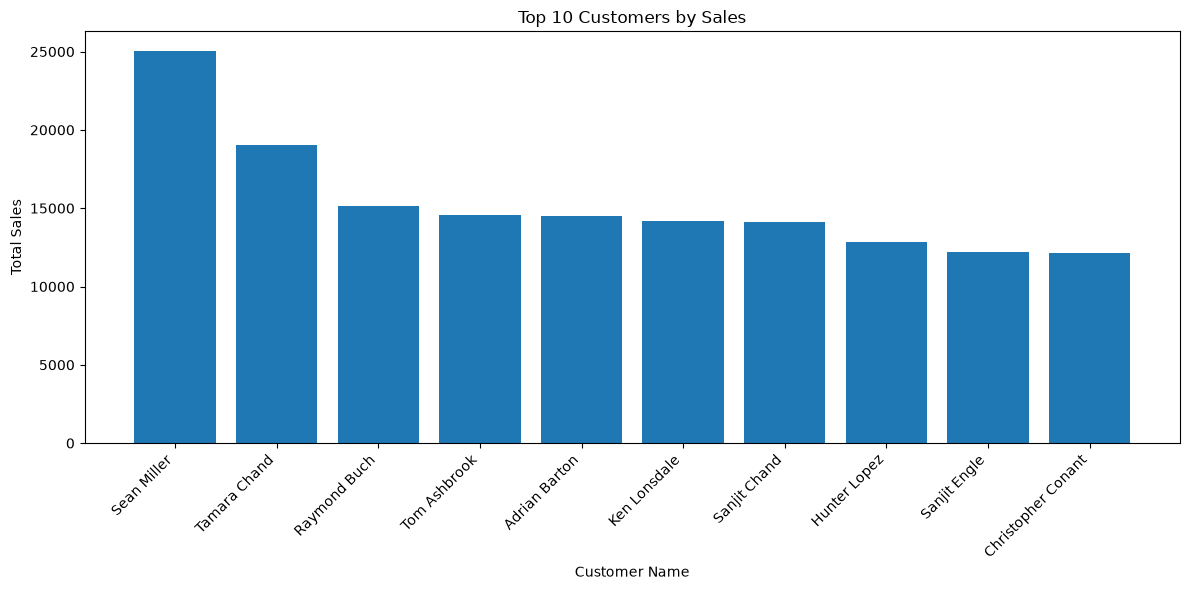

In [48]:
plt.figure(figsize=(12,6))
plt.bar(top_customers.index, top_customers.values)
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [49]:
top_profit_customers = df_clean.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False).head(10)
top_profit_customers

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

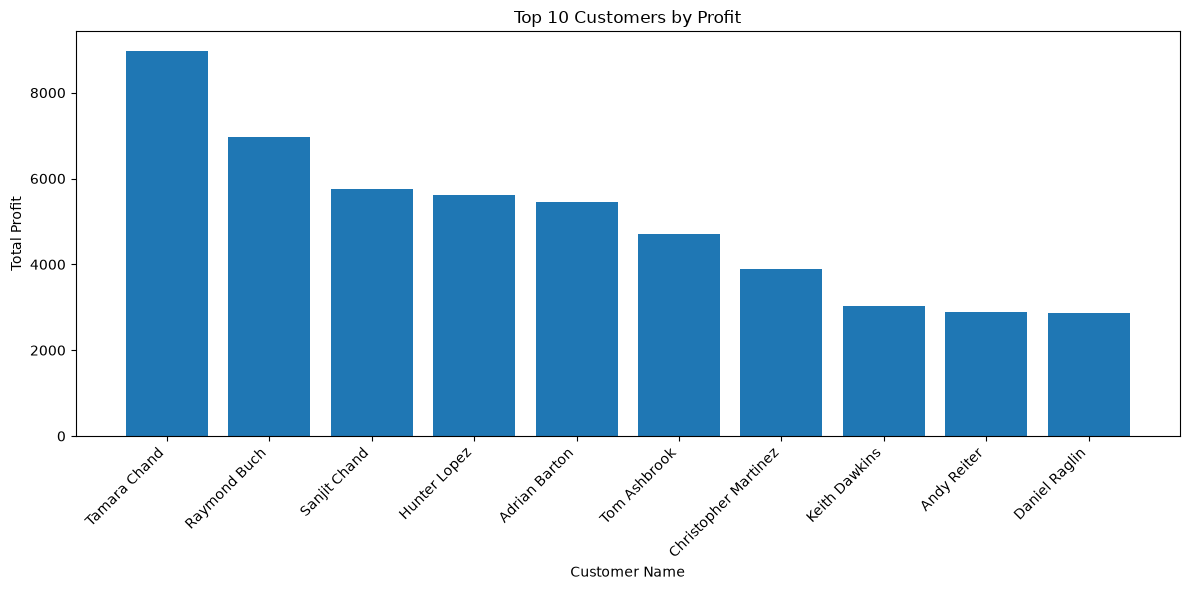

In [50]:
plt.figure(figsize=(12,6))
plt.bar(top_profit_customers.index, top_profit_customers.values)
plt.title("Top 10 Customers by Profit")
plt.xlabel("Customer Name")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [51]:
ship_mode = df_clean.groupby("Ship Mode")[["Sales", "Profit"]].sum().reset_index()
ship_mode

,Ship Mode,Sales,Profit
0,First Class,3.514284e+05,48969.8399
1,Same Day,1.283631e+05,15891.7589
2,Second Class,4.591936e+05,57446.6354
3,Standard Class,1.358216e+06,164088.7875


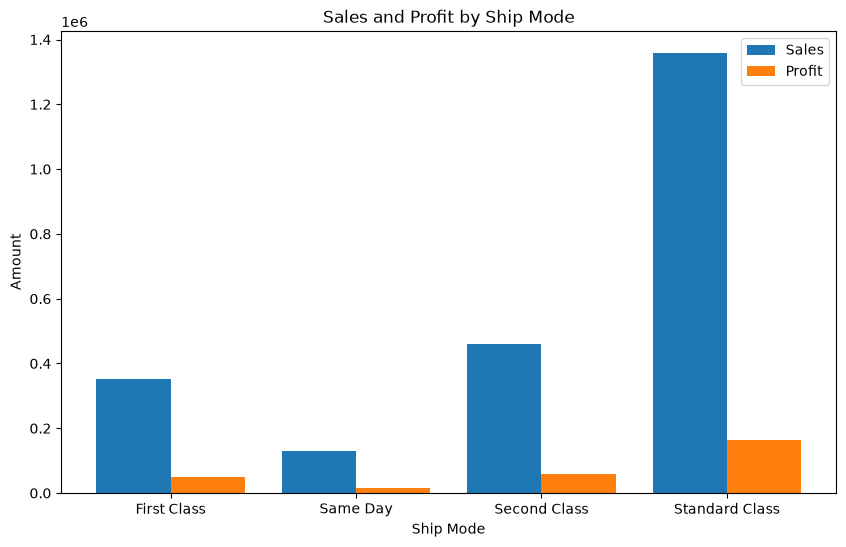

In [52]:
plt.figure(figsize=(10,6))
x = range(len(ship_mode))
plt.bar([i-0.2 for i in x], ship_mode["Sales"], width=0.4, label="Sales")
plt.bar([i+0.2 for i in x], ship_mode["Profit"], width=0.4, label="Profit")
plt.xticks(x, ship_mode["Ship Mode"])
plt.title("Sales and Profit by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Amount")
plt.legend()
plt.show()

In [53]:
discount_profit = df_clean.groupby("Discount")["Profit"].sum().reset_index()
discount_profit

,Discount,Profit
0,0.00,320987.6032
1,0.10,9029.1770
2,0.15,1418.9915
3,0.20,90337.3060
4,0.30,-10369.2774
5,0.32,-2391.1377
6,0.40,-23057.0504
7,0.45,-2493.1111
8,0.50,-20506.4281
9,0.60,-5944.6552


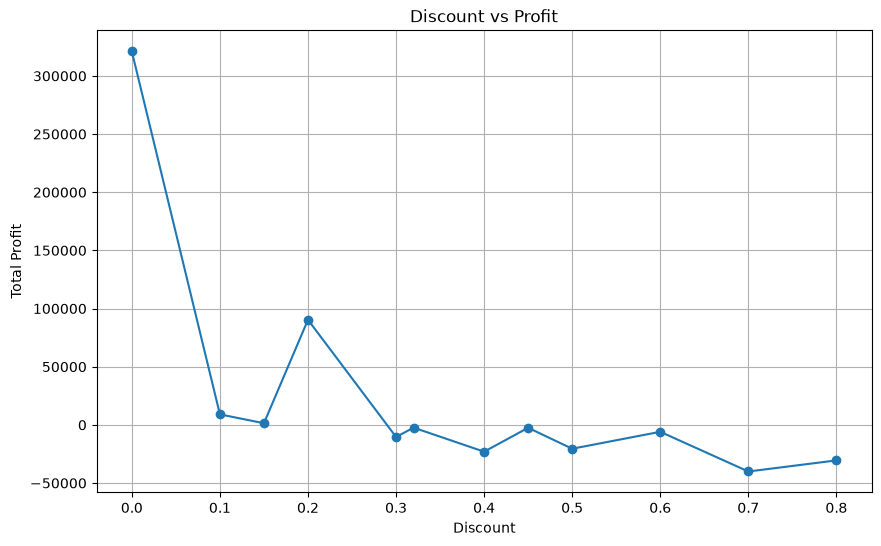

In [54]:
plt.figure(figsize=(10,6))
plt.plot(discount_profit["Discount"], discount_profit["Profit"], marker="o")
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.grid(True)
plt.show()

In [55]:
corr = df_clean[["Sales", "Quantity", "Discount", "Profit"]].corr()
corr

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


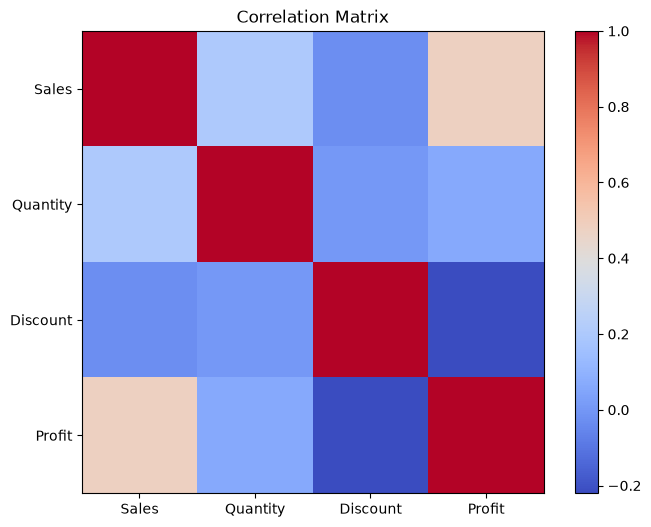

In [56]:
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [57]:
corr

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


In [58]:
corr["Profit"].sort_values(ascending=False)

Profit      1.000000
Sales       0.479064
Quantity    0.066253
Discount   -0.219487
Name: Profit, dtype: float64

In [59]:
print("Total Sales:", df_clean["Sales"].sum())
print("Total Profit:", df_clean["Profit"].sum())
print("Total Quantity:", df_clean["Quantity"].sum())
print("Average Discount:", df_clean["Discount"].mean())
print("Average Profit:", df_clean["Profit"].mean())

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity: 37873
Average Discount: 0.1562027216329798
Average Profit: 28.65689630778467


In [60]:
print("Best Category by Sales:")
print(df_clean.groupby("Category")["Sales"].sum().idxmax())

print("Best Category by Profit:")
print(df_clean.groupby("Category")["Profit"].sum().idxmax())

print("Best Region by Sales:")
print(df_clean.groupby("Region")["Sales"].sum().idxmax())

print("Best Region by Profit:")
print(df_clean.groupby("Region")["Profit"].sum().idxmax())

Best Category by Sales:
Technology
Best Category by Profit:
Technology
Best Region by Sales:
West
Best Region by Profit:
West
